# Datenaufbereitung (2. Schritt)

Im Grundgerüst für die Python-Datenanalyse gibt es folgende vier Schritte:
1. Fragestellung und Datenbeschaffung
2. **Datenaufbereitung**
3. Statistik der Rohdaten
4. Analyse der Daten

Die Datenaufbereitung ist ein wichtiger Schritt in der Datenanalyse, da die Qualität der Daten einen direkten Einfluss auf die Ergebnisse der Analyse hat. In diesem Schritt werden die Rohdaten bereinigt, transformiert und in ein geeignetes Format gebracht, um eine effektive Analyse zu ermöglichen.

## Langes vs. breites Format (Long vs. Wide Format)

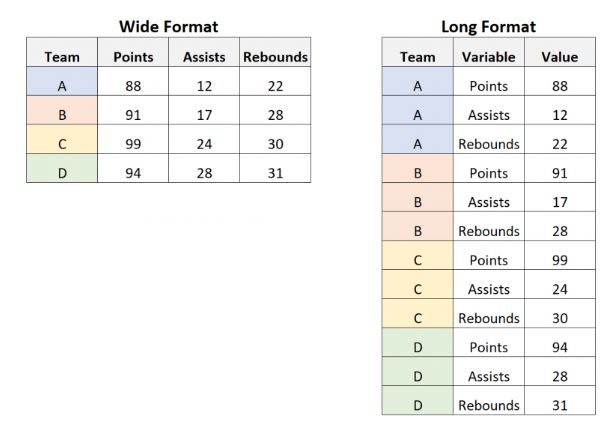

Daten können im langen (long) oder breiten (wide) Format dargestellt werden. Das Bild veranschaulicht die beiden Formate.

**Frage:** Welches Format haben die Daten in *Our World in Data*?

Pandas ermöglicht den Wechsel von einem Format in das andere mit folgenden Methoden:
- langes Format $\rightarrow$ breites Format: Methode `pivot`
- breites Format $\rightarrow$ langes Format: Methode `melt`

Das Pandas-Cheat-Sheet zeigt dies grafisch:

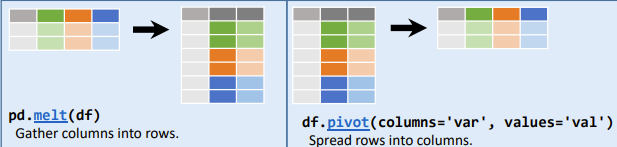

## Melting und Pivoting

*... mit der Lebenserwartung vom Bundesamt für Statistik...*

### Pandas DataFrame in das lange Format "schmelzen" (melting)

Die `melt`-Methode eines `DataFrame` wird [hier](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) beschrieben. Sie hat die folgenden Hauptargumente:
- `id_vars`: Liste der Spalte(n), die als Identifikationsvariablen verwendet werden sollen. Dies sind die Spalten, die keine Messwerte enthalten, sondern Informationen meist in Form von Zeichenfolgen (wie Land, Geschlecht usw.).
- `value_vars`: Liste der Spalte(n) mit Werten, die im langen Format angeordnet werden sollen. Wenn nicht angegeben, werden alle Spalten verwendet, die nicht als id_vars gesetzt sind.
- `var_name`: Name für die 'Variable'-Spalte, die die früheren Spaltennamen enthalten wird.
- `value_name`: Name für die 'Value'-Spalte (Wert-Spalte).

Wir werden demonstrieren, wie `melt` funktioniert, indem wir Lebenserwartungsdaten vom *Bundesamt für Statistik* (nicht von *Our World in Data*) verwenden. Diese befinden sich in einer Excel-Datei und sehen so aus:

![image.png]()

In [1]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [29]:
import pandas as pd

# load the swiss life expectancy data which is in wide format
df_ch = pd.read_excel('su-d-01.04.02.03.01.xlsx', header=3, skipfooter=4,
                      names = ['Jahr','Männer0','Frauen0','Männer20','Frauen20','Männer65','Frauen65'])
df_ch

,Jahr,Männer0,Frauen0,Männer20,Frauen20,Männer65,Frauen65
0,1981,72.4,79.2,53.7,60.1,14.3,18.2
1,1985,73.5,80.2,54.7,61.0,14.9,19.0
2,1990,74.0,80.8,55.0,61.6,15.3,19.4
3,1995,75.3,81.8,56.2,62.4,16.1,20.2
4,2000,76.9,82.6,57.7,63.2,17.0,20.7
5,2005,78.7,83.9,59.4,64.3,18.1,21.6
6,2010,80.2,84.6,60.7,65.1,18.9,22.2
7,2014,81.0,85.2,61.5,65.6,19.4,22.4
8,2015,80.7,84.9,61.3,65.3,19.2,22.2
9,2016,81.5,85.3,61.9,65.7,19.8,22.6


**Übung 1:** Verwenden Sie die folgenden Schritte, um `df_ch` in das lange Format zu bringen:
1. Verwenden Sie die Methode `df_ch.melt`
2. Beginnen Sie mit dem Argument `id_vars`
3. Benennen Sie dann die Spalten mit `var_name` und `value_name`

In [32]:
df_ch_long = df_ch.melt(id_vars=['Jahr'], var_name='GeschlechtAlter', value_name='Lebenserwartung')
df_ch_long

,Jahr,GeschlechtAlter,Lebenserwartung
0,1981,Männer0,72.4
1,1985,Männer0,73.5
2,1990,Männer0,74.0
3,1995,Männer0,75.3
4,2000,Männer0,76.9
...,...,...,...
91,2018,Frauen65,22.7
92,2019,Frauen65,22.7
93,2020,Frauen65,22.2
94,2021,Frauen65,22.7


**Übung 2:** Teilen Sie nun die Spalte `GeschlechtAlter` in zwei neue Spalten `Geschlecht` und `Alter` auf. Verwenden Sie eine `for`-Schleife und die `.loc`-Methode des Dataframes:

In [34]:
for irow in range(len(df_ch_long)):
    geschlecht_alter = df_ch_long.loc[irow,"GeschlechtAlter"]
    geschlecht = geschlecht_alter[0:6]
    alter = geschlecht_alter[6:0]
    df_ch_long.loc[irow,"Geschlecht"] = geschlecht
    df_ch_long.loc[irow,"Alter"] = alter
    
df_ch_long.loc[:,['Jahr','Geschlecht','Alter','Lebenserwartung']]

,Jahr,Geschlecht,Alter,Lebenserwartung
0,1981,Männer,,72.4
1,1985,Männer,,73.5
2,1990,Männer,,74.0
3,1995,Männer,,75.3
4,2000,Männer,,76.9
...,...,...,...,...
91,2018,Frauen,,22.7
92,2019,Frauen,,22.7
93,2020,Frauen,,22.2
94,2021,Frauen,,22.7


### Pivotieren in das breite Format mit der `.pivot`-Methode

Nachdem Sie einen `DataFrame` mit `melt` in ein langes Format gebracht haben, möchten Sie diesen Prozess vielleicht mit `pivot` umkehren. Dies ist besonders nützlich, wenn Sie Ihre Daten in einem breiten Format analysieren möchten, das oft leichter zu lesen ist und für bestimmte Arten von Visualisierungen besser geeignet sein kann. Die `pivot`-Methode in Pandas ermöglicht es Ihnen, Daten auf diese Weise zu transformieren oder umzuformen.

Die wichtigsten Argumente für `pivot` sind:
- `index`: Spalte(n), die als Index des neuen DataFrames verwendet werden sollen. Wenn Sie mehrere Identifikatoren haben, sollten Sie sicherstellen, dass alle enthalten sind.
- `columns`: Spalte(n), die als Spalten des neuen DataFrames verwendet werden sollen.
- `values`: Spalte(n), die die eigentlichen Daten enthalten, die Sie umformen möchten; wenn nicht angegeben, werden alle verbleibenden Spalten verwendet.

Wenn man jedoch mit mehreren Identifikationsspalten im langen Format arbeitet, ist es wichtig, diese korrekt zu handhaben, um einen `ValueError` aufgrund doppelter Einträge zu vermeiden. Jede Kombination von Schlüsselspalten sollte eindeutig sein, sonst kann `pivot` den DataFrame nicht korrekt umformen.

**Übung 3:** Verwenden Sie die `.pivot`-Methode, um `df_ch_long` wieder in die ursprüngliche Form `df_ch` zu bringen:

In [36]:
df_ch_long.pivot_table(index='Jahr', columns=['GeschlechtAlter'], values='Lebenserwartung')

GeschlechtAlter,Frauen0,Frauen20,Frauen65,Männer0,Männer20,Männer65
Jahr,,,,,,
1981,79.2,60.1,18.2,72.4,53.7,14.3
1985,80.2,61.0,19.0,73.5,54.7,14.9
1990,80.8,61.6,19.4,74.0,55.0,15.3
1995,81.8,62.4,20.2,75.3,56.2,16.1
2000,82.6,63.2,20.7,76.9,57.7,17.0
2005,83.9,64.3,21.6,78.7,59.4,18.1
2010,84.6,65.1,22.2,80.2,60.7,18.9
2014,85.2,65.6,22.4,81.0,61.5,19.4
2015,84.9,65.3,22.2,80.7,61.3,19.2


Verwenden Sie nun nur `Alter` für das `columns`-Argument. Was passiert? Erklären Sie den Fehler!

In [39]:
df_ch_long.pivot_table(index='Jahr', columns=['Alter'], values='Lebenserwartung')

Alter,
Jahr,
1981,49.650000
1985,50.550000
1990,51.016667
1995,52.000000
2000,53.016667
2005,54.333333
2010,55.283333
2014,55.850000
2015,55.600000


### Pivotieren in das breite Format mit der `.pivot_table`-Methode

Die `pivot_table`-Methode in Pandas ermöglicht komplexes Umformen und Aggregieren von Daten. Im Gegensatz zur `pivot`-Methode kann `pivot_table` doppelte Einträge für die angegebenen Index-/Spaltenpaare verarbeiten, indem eine Aggregationsfunktion angewendet wird, um diese Werte zu kombinieren.

Hier sind die wichtigsten Argumente für `pivot_table`:
- `values`: Die zu aggregierende Spalte; dies sind die Daten, an denen Sie interessiert sind.
- `index`: Die Spalte(n), nach der/denen im Index der Pivot-Tabelle gruppiert werden soll. Wenn ein Array übergeben wird, wird es auf die gleiche Weise wie Spaltenwerte verwendet.
- `columns`: Die Spalte(n), nach der/denen in den Spalten der Pivot-Tabelle gruppiert werden soll. Funktioniert wie `index`.
- `aggfunc`: Die Aggregationsfunktion, die zum Kombinieren von Daten verwendet werden soll. Gängige Funktionen sind `sum`, `mean`, `std`, `min`, `max` und viele andere. Dies ist entscheidend, da es definiert, wie die Daten konsolidiert werden. Verschiedene Funktionen können sehr unterschiedliche Erkenntnisse liefern, daher ist die Wahl der richtigen Funktion für eine genaue Analyse unerlässlich.

**Übung 4:** Um den obigen Fehler zu beheben, verwenden Sie die `.pivot_table`-Methode zusammen mit der `mean`-Aggregation (Mittelwert).

In [40]:
df_ch_long.pivot_table(index='Jahr', columns='Alter', values='Lebenserwartung',aggfunc='mean')

Alter,
Jahr,
1981,49.650000
1985,50.550000
1990,51.016667
1995,52.000000
2000,53.016667
2005,54.333333
2010,55.283333
2014,55.850000
2015,55.600000


## Datensätze kombinieren

*... unter Verwendung der Lebenserwartungsdaten von Our World in Data...*

In Pandas werden sowohl `pd.merge` als auch `pd.concat` verwendet, um Datensätze zu kombinieren, aber sie dienen unterschiedlichen Zwecken und funktionieren auf unterschiedliche Weise. Die `concat`-Methode wird verwendet, um Pandas-Objekte entlang einer bestimmten Achse (zeilenweise oder spaltenweise) zu verketten, mit optionaler Mengenlogik entlang der anderen Achsen. Sie ist nützlich, wenn Sie Daten in ähnlichen Strukturen haben, die gestapelt werden müssen, wie das Anhängen von Zeilen aus einem Datensatz an einen anderen oder das Nebeneinanderstellen von Spalten. Im Gegensatz dazu geht es bei der `merge`-Methode eher darum, Datensätze zu kombinieren, indem Zeilen mithilfe eines oder mehrerer Schlüssel (wie bei Datenbank-Join-Operationen) verknüpft werden. Es ist eine Möglichkeit, einen Datensatz mit Informationen aus einem anderen zu erweitern oder anzureichern, indem auf einer Schlüsselspalte oder einem Index abgeglichen wird.

Wichtige Unterschiede zwischen `concat` und `merge`:
- `concat` kombiniert DataFrames über Zeilen oder Spalten hinweg, während `merge` DataFrames basierend auf gemeinsamen Schlüsseln verknüpft.
- `concat` kann nur die Ausrichtung des Index (zeilenweise) oder der Spalten (spaltenweise) handhaben, während `merge` Daten basierend auf den Werten ausrichtet.

### Verketten von DataFrames mit Pandas

Beim Verketten (Concatenation) in Pandas geht es im Wesentlichen um das Stapeln oder Ausrichten von Daten. Die `concat`-Funktion in Pandas wird verwendet, um entweder Spalten oder Zeilen von einem DataFrame an einen anderen anzuhängen und so einen einzigen DataFrame aus mehreren Quellen zu erstellen. Diese Methode ist ideal, wenn Sie mehrere Datensätze mit denselben Feldern (Spalten) haben oder wenn Sie Datensätze mit denselben Indizes, aber unterschiedlichen Spalten zusammenführen möchten. Aus dem Cheat-Sheet:

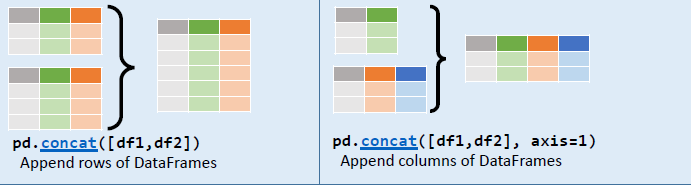

Wichtige Argumente für `concat`:
- `objs`: Eine Liste von DataFrame-Objekten.
- `axis`: Die Achse, entlang der verkettet werden soll; `axis=0` ist Standard und stapelt Zeilen, `axis=1` stapelt Spalten.
- `join`: Wie Indizes auf der/den anderen Achse(n) behandelt werden sollen. `join='outer'` nimmt die Vereinigung aller, `join='inner'` nimmt die Schnittmenge.
- `ignore_index`: Wenn `True`, werden die Indexwerte entlang der Verkettungsachse nicht verwendet. Die resultierende Achse wird mit 0, 1, ..., n - 1 beschriftet.

**Übung 5:** Laden Sie die Lebenserwartungsdaten von Our World in Data, wählen Sie die Daten für die Schweiz und Schweden aus und erstellen Sie zwei DataFrames, einen für die Schweiz und einen für Schweden. Verketten Sie dann die beiden DataFrames, indem Sie die Zeilen stapeln.

In [42]:
df = pd.read_csv('life-expectancy.csv', skiprows=1, names=['Gebiet','Code','Jahr','Lebenserwartung'])
df_ch = df[df['Gebiet']=='Switzerland']
df_swe = df[df['Gebiet']=='Sweden']

print('Number of rows in df_ch: ', df_ch.shape[0])
print('Number of rows in df_swe: ', df_swe.shape[0])

# Concat by stacking the dataframes on top of each other
df_combined = pd.concat([df_ch, df_swe], axis=0)    

print('Number of rows in df_combined: ', df_combined.shape[0])

Number of rows in df_ch:  146
Number of rows in df_swe:  271
Number of rows in df_combined:  417


In [44]:
df

,Gebiet,Code,Jahr,Lebenserwartung
0,Afghanistan,AFG,1950,27.7275
1,Afghanistan,AFG,1951,27.9634
2,Afghanistan,AFG,1952,28.4456
3,Afghanistan,AFG,1953,28.9304
4,Afghanistan,AFG,1954,29.2258
...,...,...,...,...
20750,Zimbabwe,ZWE,2017,60.7095
20751,Zimbabwe,ZWE,2018,61.4141
20752,Zimbabwe,ZWE,2019,61.2925
20753,Zimbabwe,ZWE,2020,61.1242


### Zusammenführen (Mergen) von DataFrames mit Pandas

Die `merge`-Funktion in Pandas ist ein mächtiges Werkzeug, um verschiedene Datensätze zu einem einzigen zu kombinieren. Der Zweck von `merge` ist es, Daten aus verschiedenen Quellen basierend auf gemeinsamen Identifikatoren, sogenannten Schlüsseln (Keys), zu verknüpfen. In Datenbanken und Pandas sind Schlüssel eindeutige Identifikatoren für Datenzeilen. Sie sind wie ein Index in einem Buch: Wenn Sie den Indexbegriff kennen, können Sie schnell alle relevanten Informationen zu diesem Thema finden. Ähnlich verhält es sich bei Datenoperationen: Wenn Sie den Schlüssel kennen, können Sie verwandte Informationen über verschiedene Tabellen oder Datensätze hinweg finden und abgleichen.

Hier ist eine vereinfachte Erklärung des Konzepts der Schlüssel:

- **Schlüssel (Keys):** Dies sind spezifische Spalten in Ihren Datentabellen (DataFrames in Pandas), die verwendet werden, um Zeilen von einer Tabelle mit einer anderen abzugleichen und zusammenzuführen. Stellen Sie sie sich als die gemeinsamen Fragen auf zwei getrennten Formularen vor, die es Ihnen ermöglichen, die Antworten von jedem Formular derselben Person zuzuordnen.
  
  Wenn Sie beispielsweise eine Spalte `customer_id` in beiden Datensätzen haben, die jeden Kunden eindeutig identifiziert, kann diese Spalte als Schlüssel zum Zusammenführen von Daten verwendet werden. Auf diese Weise können Sie Transaktionen mit Kundenprofilen abgleichen, auch wenn die Informationen ursprünglich in zwei getrennten Datensätzen vorliegen.
  
- **Arten von Merges:** Genauso wie es verschiedene Möglichkeiten gibt, Teile eines Puzzles zu kombinieren, gibt es verschiedene Arten von Merges:
  - **Inner Merge:** Dies ist wie das Finden der Schnittmenge zweier Mengen; nur die Schlüssel, die in beiden Datensätzen vorhanden sind, werden in den endgültigen zusammengeführten Datensatz aufgenommen.
  - **Outer Merge:** Dies ist wie die Vereinigung zweier Mengen; alle Schlüssel aus beiden Datensätzen werden aufgenommen, und wo es keine Übereinstimmung gibt, erhalten die Daten fehlende Werte (`NaN`).
  - **Left Merge:** Dies bedeutet so viel wie: "Behalte alles aus dem linken Datensatz und füge, wo immer möglich, Informationen aus dem rechten Datensatz basierend auf den Schlüsseln hinzu. Wenn es keine Übereinstimmung gibt, lasse Leerstellen (d. h. `NaN`)."
  - **Right Merge:** Dies ist das Gegenteil eines Left Merge; behalte alles aus dem rechten Datensatz und fülle, wo möglich, mit Daten aus dem linken Datensatz auf.

Die `merge`-Funktion wird verwendet, um Daten auf sinnvolle Weise zu kombinieren, wenn es einen gemeinsamen Schlüssel oder Identifikator gibt, der die Datensätze verknüpft. Das Cheat-Sheet erklärt es auf diese Weise:

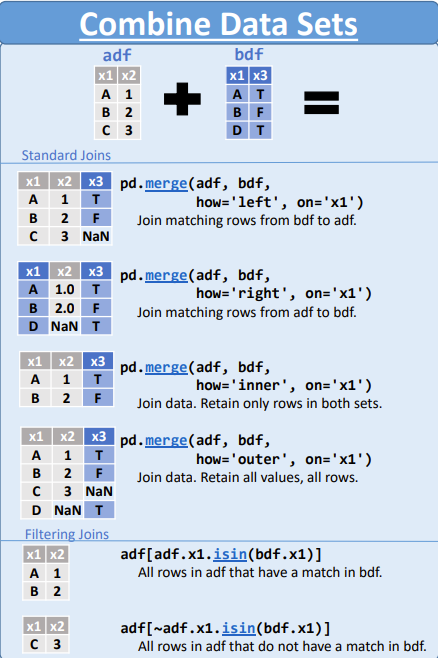

Hier sind die wichtigsten Argumente für `merge` (siehe die vollständige Beschreibung [hier](https://pandas.pydata.org/docs/reference/api/pandas.merge.html#pandas.merge)):
- `left`, `right`: Die beiden DataFrames, die zusammengeführt werden sollen.
- `on`: Spalten- oder Indexnamen, die als Schlüssel für den Join verwendet werden sollen. Diese müssen in beiden DataFrames vorhanden sein.
- `left_on`: Spalten aus dem linken DataFrame, die als Schlüssel verwendet werden sollen.
- `right_on`: Spalten aus dem rechten DataFrame, die als Schlüssel verwendet werden sollen.
- `how`: Art des durchzuführenden Merges. Dazu gehören:
  - `inner`: Nur die gemeinsamen Schlüssel in beiden DataFrames werden aufgenommen (Schnittmenge).
  - `outer`: Alle Schlüssel aus beiden DataFrames werden aufgenommen (Vereinigung).
  - `left`: Nur Schlüssel aus dem linken DataFrame werden aufgenommen.
  - `right`: Nur Schlüssel aus dem rechten DataFrame werden aufgenommen.
- `suffixes`: Ein Tupel von Zeichenfolgen-Suffixen, die auf überlappende Spalten angewendet werden.

Die Verwendung des richtigen Merge-Typs ist entscheidend für die beabsichtigte Analyse. Ein `inner` Merge verliert Zeilen, die nicht in beiden DataFrames übereinstimmen, während ein `outer` Merge alle Zeilen behält, aber `NaN`-Werte für Nicht-Übereinstimmungen einführt.

**Übung 6:** Aus der vorherigen Übung haben wir zwei DataFrames `df_ch` und `df_swe`. Versuchen Sie, diese mit `Jahr` als gemeinsamen Schlüssel zusammenzuführen (mergen). Sie müssen die `suffixes` verwenden, da es gemeinsame Spalten gibt. Probieren Sie verschiedene Einstellungen für `how` aus.

In [45]:
pd.merge(df_ch, df_swe, on='Jahr', suffixes=('_ch','_swe'),how='outer')

,Gebiet_ch,Code_ch,Jahr,Lebenserwartung_ch,Gebiet_swe,Code_swe,Lebenserwartung_swe
0,NaN,NaN,1751,NaN,Sweden,SWE,38.4300
1,NaN,NaN,1752,NaN,Sweden,SWE,35.4100
2,NaN,NaN,1753,NaN,Sweden,SWE,39.7400
3,NaN,NaN,1754,NaN,Sweden,SWE,37.5000
4,NaN,NaN,1755,NaN,Sweden,SWE,36.5800
...,...,...,...,...,...,...,...
266,Switzerland,CHE,2017,83.4125,Sweden,SWE,82.4382
267,Switzerland,CHE,2018,83.5615,Sweden,SWE,82.5326
268,Switzerland,CHE,2019,83.7802,Sweden,SWE,83.0524
269,Switzerland,CHE,2020,83.0670,Sweden,SWE,82.4274


## Lösungen der Übungen im Unterricht

In [ ]:
# Exercice 1
df_ch_long = df_ch.melt(id_vars=['Jahr'], var_name='GeschlechtAlter', value_name='Lebenserwartung')
df_ch_long

In [ ]:
# Exercice 2
for i in range(len(df_ch_long)):
    sex_age = df_ch_long.loc[i, 'GeschlechtAlter']
    df_ch_long.loc[i, 'Geschlecht'] = sex_age[0:6]
    df_ch_long.loc[i, 'Alter'] = int(sex_age[6:])

df_ch_long

In [ ]:
# Exercice 3
df_ch_long.pivot_table(index='Jahr', columns=['GeschlechtAlter'], values='Lebenserwartung')

In [ ]:
# Exercice 4
df_ch_long.pivot_table(index='Jahr', columns='Alter', values='Lebenserwartung',aggfunc='mean')

In [ ]:
# Exercice 5
# load the life expectancy from our world in data and select the data for Switzerland and Sweden
df = pd.read_csv('life-expectancy.csv', skiprows=1, names=['Gebiet','Code','Jahr','Lebenserwartung'])
df_ch = df[df['Gebiet']=='Switzerland']
df_swe = df[df['Gebiet']=='Sweden']

print('Number of rows in df_ch: ', df_ch.shape[0])
print('Number of rows in df_swe: ', df_swe.shape[0])

# Concat by stacking the dataframes on top of each other
df_combined = pd.concat([df_ch, df_swe], axis=0)    

print('Number of rows in df_combined: ', df_combined.shape[0])

In [ ]:
# Exercice 6
pd.merge(df_ch, df_swe, on='Jahr', suffixes=('_ch','_swe'),how='outer')